<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 0.558
  Empty          : 2.970
  Functional     : 0.293
  Scum           : 0.178


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 1.0553 acc 0.530 | val loss 1.5351 acc 0.616 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.7909 acc 0.633 | val loss 0.9180 acc 0.631 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.6232 acc 0.719 | val loss 0.5570 acc 0.739 *


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.5200 acc 0.743 | val loss 0.7010 acc 0.724


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.4319 acc 0.772 | val loss 0.8105 acc 0.567


...

[ResNet-18] Epoch  21/100 | LR: 6.25e-05 | train loss 0.0432 acc 0.979 | val loss 0.3230 acc 0.882


[ResNet-18] Epoch  22/100 | LR: 6.25e-05 | train loss 0.0323 acc 0.990 | val loss 0.2955 acc 0.897


[ResNet-18] Epoch  23/100 | LR: 3.13e-05 | train loss 0.0388 acc 0.984 | val loss 0.3208 acc 0.897


[ResNet-18] Epoch  24/100 | LR: 3.13e-05 | train loss 0.0347 acc 0.984 | val loss 0.3026 acc 0.906


[ResNet-18] Epoch  25/100 | LR: 3.13e-05 | train loss 0.0295 acc 0.987 | val loss 0.2747 acc 0.906

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 25.

[ResNet-18] Restored best checkpoint (val loss = 0.2576)


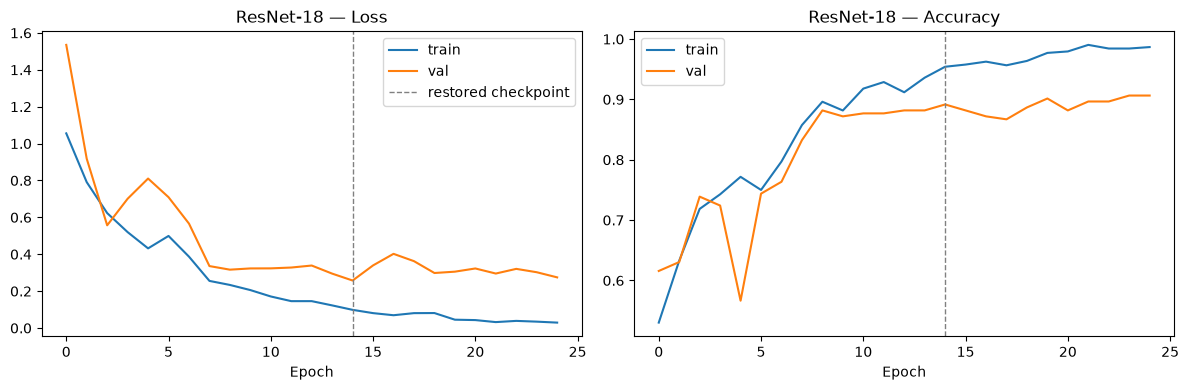

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.560


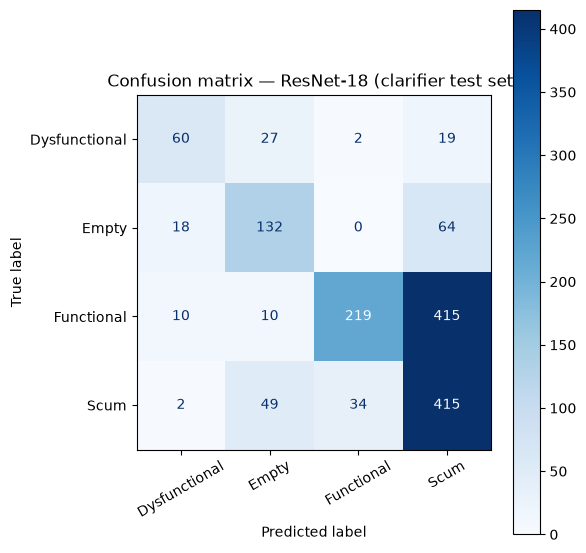

               precision    recall  f1-score   support

Dysfunctional      0.667     0.556     0.606       108
        Empty      0.606     0.617     0.611       214
   Functional      0.859     0.335     0.482       654
         Scum      0.455     0.830     0.587       500

     accuracy                          0.560      1476
    macro avg      0.646     0.584     0.572      1476
 weighted avg      0.671     0.560     0.545      1476



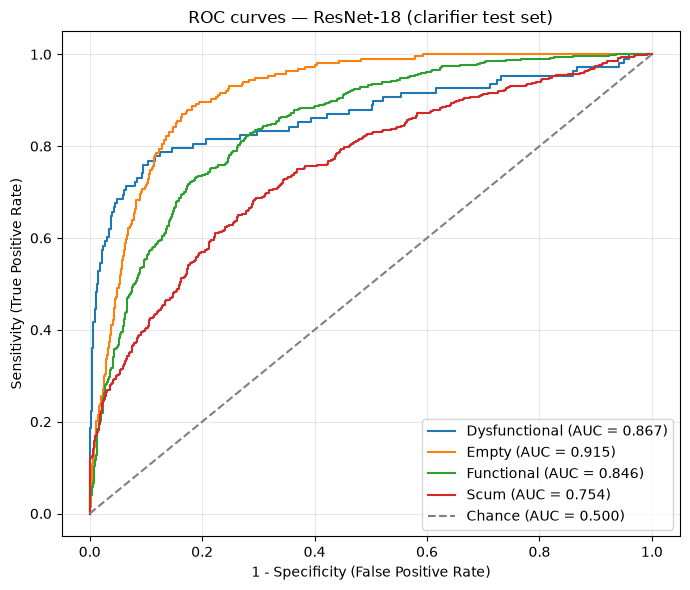

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.867
  Empty          : 0.915
  Functional     : 0.846
  Scum           : 0.754

Mean AUC (over 4/4 classes with test examples): 0.845


(np.float64(0.559620596205962),
 {'Dysfunctional': 0.8674396252978124,
  'Empty': 0.9145252306826429,
  'Functional': 0.8462372672009048,
  'Scum': 0.7536926229508196})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_CapeFlats.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
